<a href="https://colab.research.google.com/github/antonellagambarte/proyecto-final-CEIA/blob/main/umbral_f2_score_PRUEBA_ETAPA_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

In [ ]:
ruta_archivo_train = '/content/drive/My Drive/NHANES/dataset_train_imputado.csv'
ruta_archivo_test = '/content/drive/My Drive/NHANES/dataset_test_imputado.csv'


df_train = pd.read_csv(ruta_archivo_train)
df_test = pd.read_csv(ruta_archivo_test)

In [ ]:
df_train.head()

,edad,genero,colesterol_total,hdl,ldl,trigliceridos,proteina_c,bmi,fumo_100_cigarrillos,fumador_actual,...,act_moderada_9.0,prediabetes_glucosa_alterada_2.0,prediabetes_glucosa_alterada_3.0,prediabetes_glucosa_alterada_9.0,colesterol_alto_2.0,colesterol_alto_9.0,riñones_debiles_fallando_2.0,riñones_debiles_fallando_9.0,asma_2.0,asma_9.0
0,0.027815,1,0.635525,-0.409169,110.804858,1.430187,-0.633385,-0.926269,1,-0.450093,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,1.598832,1,-0.236009,0.044620,100.609504,-0.035063,-0.681892,-1.527568,0,-0.450093,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
2,0.869431,1,-0.154793,-0.056492,105.080360,-0.040414,-0.646549,-0.547527,1,2.387436,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,-0.084401,1,0.421306,0.838667,118.001130,-0.366252,-0.041933,-0.024172,0,-0.450093,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
4,-0.589371,0,0.226934,-0.409169,112.161330,0.702848,0.117120,0.260671,0,-0.450093,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4454 entries, 0 to 4453
Data columns (total 59 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   edad                                   4454 non-null   float64
 1   genero                                 4454 non-null   int64  
 2   colesterol_total                       4454 non-null   float64
 3   hdl                                    4454 non-null   float64
 4   ldl                                    4454 non-null   float64
 5   trigliceridos                          4454 non-null   float64
 6   proteina_c                             4454 non-null   float64
 7   bmi                                    4454 non-null   float64
 8   fumo_100_cigarrillos                   4454 non-null   int64  
 9   fumador_actual                         4454 non-null   float64
 10  act_vigorosa                           4454 non-null   int64  
 11  real

In [ ]:
nivel_1_basico = [
    'edad', 'genero', 'fumo_100_cigarrillos', 'actividad_deportiva_moderada_x_semana', 'anhedonia', 'consumo_alcohol_ultimo_año'
]

# ETAPA 2
nivel_2_antecedentes = [
     'bmi', 'presion_sistolica_final', 'presion_diastolica_final', 'fam_cardio_2.0','fam_cardio_9.0', 'fam_diabetes_2.0','fam_diabetes_9.0',
     'fam_asma_2.0', 'fam_asma_9.0', 'hipertension_2','hipertension_9', 'diabetes_2.0', 'diabetes_3.0','diabetes_9.0',
     'riñones_debiles_fallando_2.0','riñones_debiles_fallando_9.0', 'asma_2.0','asma_9.0'
]



# ETAPA 3: Análisis de Laboratorio
nivel_3_laboratorio = [
   'colesterol_total', 'hdl', 'trigliceridos', 'proteina_c', 'hemoglobina', 'creatinina', 'acido_urico', 'potasio'
]

In [ ]:
from sklearn.metrics import (
    roc_auc_score,
    recall_score,
    precision_score,
    f1_score,
    confusion_matrix,
    make_scorer
)
from sklearn.model_selection import cross_val_score, StratifiedKFold
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def evaluar_overfitting(
    modelo,
    X_train, y_train,
    X_test, y_test,
    threshold=0.25,
    nombre="Modelo"
):
    # --- VALIDACIÓN CRUZADA ESTRATIFICADA (Para reemplazar los valores de TEST) ---
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Definimos los scorers personalizados basados en el umbral
    def get_preds(y_true, y_probs):
        return (y_probs >= threshold).astype(int)

    def custom_recall(y_true, y_probs): return recall_score(y_true, get_preds(y_true, y_probs), zero_division=0)
    def custom_precision(y_true, y_probs): return precision_score(y_true, get_preds(y_true, y_probs), zero_division=0)
    def custom_f1(y_true, y_probs): return f1_score(y_true, get_preds(y_true, y_probs), zero_division=0)

    auc_test = np.mean(cross_val_score(modelo, X_train, y_train, cv=skf, scoring='roc_auc'))
    recall_test = np.mean(cross_val_score(modelo, X_train, y_train, cv=skf, scoring=make_scorer(custom_recall, response_method='predict_proba')))
    precision_test = np.mean(cross_val_score(modelo, X_train, y_train, cv=skf, scoring=make_scorer(custom_precision, response_method='predict_proba')))
    f1_test = np.mean(cross_val_score(modelo, X_train, y_train, cv=skf, scoring=make_scorer(custom_f1, response_method='predict_proba')))

    # --- MÉTRICAS DE TRAIN (Ajuste sobre el set completo) ---
    modelo.fit(X_train, y_train)
    prob_train = modelo.predict_proba(X_train)[:, 1]
    pred_train = (prob_train >= threshold).astype(int)

    auc_train = roc_auc_score(y_train, prob_train)
    recall_train = recall_score(y_train, pred_train)
    precision_train = precision_score(y_train, pred_train)
    f1_train = f1_score(y_train, pred_train)

    print(f"\n===== {nombre} ====")
    print("---- TRAIN (Full) ----")
    print(f"AUC: {auc_train:.4f}")
    print(f"Recall: {recall_train:.4f}")
    print(f"Precision: {precision_train:.4f}")
    print(f"F1: {f1_train:.4f}")

    print("\n---- TEST (Promedio CV 5-Folds) ----")
    print(f"AUC: {auc_test:.4f}")
    print(f"Recall: {recall_test:.4f}")
    print(f"Precision: {precision_test:.4f}")
    print(f"F1: {f1_test:.4f}")

    auc_gap = auc_train - auc_test
    recall_gap = recall_train - recall_test
    print(f"\n---- GAP (Train - CV) ----")
    print(f"AUC gap: {auc_gap:.4f}")
    print(f"Recall gap: {recall_gap:.4f}")

    # Matriz de confusión (usamos el set de test original solo para visualización)
    prob_v = modelo.predict_proba(X_test)[:, 1]
    pred_v = (prob_v >= threshold).astype(int)
    cm = confusion_matrix(y_test, pred_v)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(6,5))
    sns.heatmap(cm_normalized, annot=True, fmt=".2%", cmap="Blues", xticklabels=["Bajo", "Alto"], yticklabels=["Bajo", "Alto"])
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.title(f"Matriz Confusión (Hold-out Test) - {nombre}")
    plt.show()

    return {
        "auc_train": auc_train,
        "recall_train": recall_train,
        "precision_train": precision_train,
        "f1_train": f1_train,
        "auc_test": auc_test,
        "recall_test": recall_test,
        "precision_test": precision_test,
        "f1_test": f1_test,
        "auc_gap": auc_gap,
        "recall_gap": recall_gap
    }

In [ ]:
# Inicializamos la lista para almacenar los resultados de los modelos
results = []

In [ ]:
df_results = pd.DataFrame(results)

In [ ]:
df_train_temp = df_train.copy()
df_test_temp = df_test.copy()

In [ ]:
TARGET = "alto_riesgo"

X_train = df_train_temp.drop(columns=[TARGET])
y_train = df_train_temp[TARGET]

X_test = df_test_temp.drop(columns=[TARGET])
y_test = df_test_temp[TARGET]

In [ ]:
nivel_1_cols = [c for c in nivel_1_basico if c in X_train.columns]
nivel_2_cols = nivel_1_cols + [c for c in nivel_2_antecedentes if c in X_train.columns]
nivel_3_cols = nivel_2_cols + [c for c in nivel_3_laboratorio if c in X_train.columns]

# Definición de las etapas
etapas = [nivel_2_cols]
nombres_etapas = ["Etapa 1: Básica + Antecedentes"]

In [ ]:
X_train_etapa_1 = X_train[etapas[0]]
X_test_etapa_1 = X_test[etapas[0]]

In [ ]:
X_train_etapa_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4454 entries, 0 to 4453
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   edad                                   4454 non-null   float64
 1   genero                                 4454 non-null   int64  
 2   fumo_100_cigarrillos                   4454 non-null   int64  
 3   actividad_deportiva_moderada_x_semana  4454 non-null   float64
 4   anhedonia                              4454 non-null   float64
 5   consumo_alcohol_ultimo_año             4454 non-null   float64
 6   bmi                                    4454 non-null   float64
 7   presion_sistolica_final                4454 non-null   float64
 8   presion_diastolica_final               4454 non-null   float64
 9   fam_cardio_2.0                         4454 non-null   float64
 10  fam_cardio_9.0                         4454 non-null   float64
 11  fam_

## **Modelos originales seleccionados**

### **ramdom forrest - balanceo propio**


===== Random Forest - BP ====
---- TRAIN (Full) ----
AUC: 0.8846
Recall: 0.9421
Precision: 0.2596
F1: 0.4070

---- TEST (Promedio CV 5-Folds) ----
AUC: 0.8454
Recall: 0.9005
Precision: 0.2494
F1: 0.3906

---- GAP (Train - CV) ----
AUC gap: 0.0392
Recall gap: 0.0416


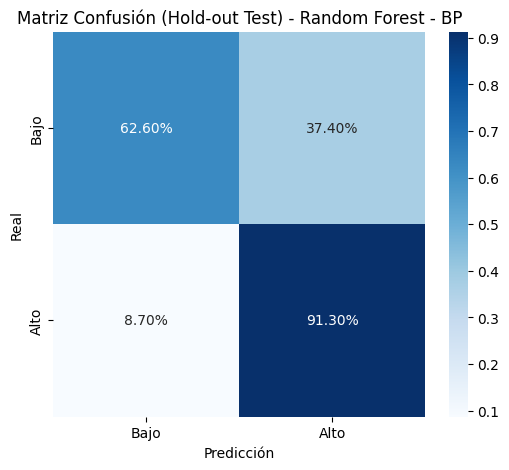

In [ ]:
# Modelo Random Forest con class_weight='balanced'
modelo_rf_balanced_weight = RandomForestClassifier(
    max_depth=5,
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

modelo_rf_balanced_weight.fit(X_train_etapa_1, y_train)

rf_balanced_weight_metrics = evaluar_overfitting(
    modelo_rf_balanced_weight,
    X_train_etapa_1, y_train,
    X_test_etapa_1, y_test,
    threshold=0.4,
    nombre="Random Forest - BP"
)

results.append({"Modelo": "Random Forest BP", **rf_balanced_weight_metrics})

### **xgboost**


===== XGBoost - BP ====
---- TRAIN (Full) ----
AUC: 0.8747
Recall: 0.9204
Precision: 0.2682
F1: 0.4153

---- TEST (Promedio CV 5-Folds) ----
AUC: 0.8551
Recall: 0.8896
Precision: 0.2636
F1: 0.4067

---- GAP (Train - CV) ----
AUC gap: 0.0195
Recall gap: 0.0308


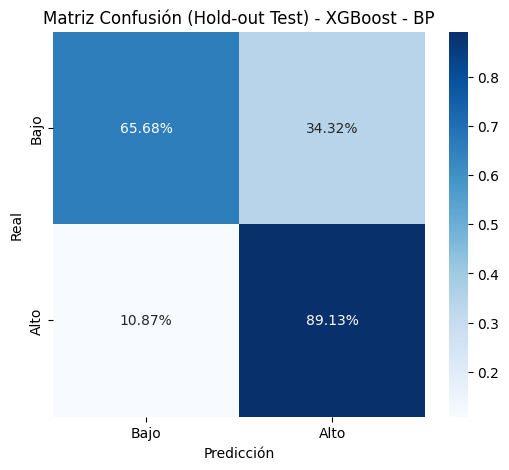

In [ ]:
from xgboost import XGBClassifier

# ratio clases para penalización
ratio = (y_train == 0).sum() / (y_train == 1).sum() #9.55

modelo_xgb = XGBClassifier(
    n_estimators=200,
    max_depth=2,
    learning_rate=0.03,
    subsample=0.6,
    colsample_bytree=0.8,
    min_child_weight=2,
    scale_pos_weight=ratio,
    eval_metric="aucpr",
    random_state=42
)

modelo_xgb.fit(X_train_etapa_1, y_train)

xgb_metrics = evaluar_overfitting(
    modelo_xgb,
    X_train_etapa_1, y_train,
    X_test_etapa_1, y_test,
    threshold=0.4,
    nombre="XGBoost - BP"
)

results.append({"Modelo": "XGBoost - BP", **xgb_metrics})

### **ramdom forrest con undersampling**

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

undersampler = RandomUnderSampler(
    sampling_strategy=0.8,
    random_state=42
)

X_train_under, y_train_under = undersampler.fit_resample(X_train_etapa_1, y_train)

print("Antes Undersampling:")
print(y_train.value_counts())

print("\nDespués Undersampling:")
print(y_train_under.value_counts())

Antes Undersampling:
alto_riesgo
0    3901
1     553
Name: count, dtype: int64

Después Undersampling:
alto_riesgo
0    691
1    553
Name: count, dtype: int64



===== Random Forest (Undersampling) ====
---- TRAIN (Full) ----
AUC: 0.9022
Recall: 0.9277
Precision: 0.6999
F1: 0.7978

---- TEST (Promedio CV 5-Folds) ----
AUC: 0.8506
Recall: 0.8879
Precision: 0.6655
F1: 0.7606

---- GAP (Train - CV) ----
AUC gap: 0.0517
Recall gap: 0.0398


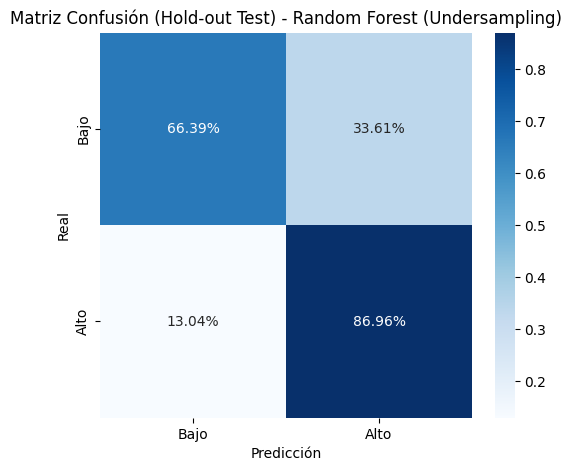

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Modelo Random Forest con Undersampling
modelo_rf_under = RandomForestClassifier(
    max_depth=5,
    n_estimators=100,
    random_state=42
)

modelo_rf_under.fit(X_train_under, y_train_under)

rf_under_metrics = evaluar_overfitting(
    modelo_rf_under,
    X_train_under, y_train_under,
    X_test_etapa_1, y_test,
    threshold=0.4,
    nombre="Random Forest (Undersampling)"
)

results.append({"Modelo": "Random Forest (Undersampling)", **rf_under_metrics})

In [ ]:
import pandas as pd

df_results = pd.DataFrame(results)

print("pruebas con balanceo:")
df_results

pruebas con balanceo:


,Modelo,auc_train,recall_train,precision_train,f1_train,auc_test,recall_test,precision_test,f1_test,auc_gap,recall_gap
0,Random Forest BP,0.884558,0.942134,0.259591,0.407031,0.845405,0.900524,0.249388,0.390590,0.039153,0.041610
1,XGBoost - BP,0.874670,0.920434,0.268177,0.415341,0.855138,0.889631,0.263645,0.406746,0.019532,0.030803
2,Random Forest (Undersampling),0.902240,0.927667,0.699864,0.797823,0.850568,0.887912,0.665476,0.760593,0.051672,0.039756


## **Búsqueda de hiperparámetros para etapa 1 con Optuna (maximización de f2-score y busqueda de umbral)**

In [ ]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 14.7 MB/s eta 0:00:00


In [ ]:
import optuna
from sklearn.metrics import fbeta_score
from sklearn.model_selection import cross_val_score, StratifiedKFold

def objective_rf_bp(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'class_weight': 'balanced',
        'random_state': 42
    }
    threshold = trial.suggest_float('threshold', 0.2, 0.6)

    clf = RandomForestClassifier(**params)
    # Usamos validación cruzada para evitar sobreajuste
    skf = StratifiedKFold(n_splits=5)
    scores = []

    for train_idx, val_idx in skf.split(X_train_etapa_1, y_train):
        X_t, X_v = X_train_etapa_1.iloc[train_idx], X_train_etapa_1.iloc[val_idx]
        y_t, y_v = y_train.iloc[train_idx], y_train.iloc[val_idx]

        clf.fit(X_t, y_t)
        probs = clf.predict_proba(X_v)[:, 1]
        preds = (probs >= threshold).astype(int)
        scores.append(fbeta_score(y_v, preds, beta=2))

    return np.mean(scores)

def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 2, 6),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 0.9),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 5, 15),
        'random_state': 42,
        'eval_metric': 'aucpr'
    }
    threshold = trial.suggest_float('threshold', 0.2, 0.6)

    clf = XGBClassifier(**params)
    skf = StratifiedKFold(n_splits=5)
    scores = []
    for train_idx, val_idx in skf.split(X_train_etapa_1, y_train):
        X_t, X_v = X_train_etapa_1.iloc[train_idx], X_train_etapa_1.iloc[val_idx]
        y_t, y_v = y_train.iloc[train_idx], y_train.iloc[val_idx]
        clf.fit(X_t, y_t)
        probs = clf.predict_proba(X_v)[:, 1]
        preds = (probs >= threshold).astype(int)
        scores.append(fbeta_score(y_v, preds, beta=2))
    return np.mean(scores)

def objective_rf_under(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'random_state': 42
    }
    sampling_strategy = trial.suggest_float('sampling_strategy', 0.5, 1.0)
    threshold = trial.suggest_float('threshold', 0.2, 0.6)


    undersampler_trial = RandomUnderSampler(sampling_strategy=sampling_strategy, random_state=42)
    X_res, y_res = undersampler_trial.fit_resample(X_train_etapa_1, y_train)

    clf = RandomForestClassifier(**params)
    skf = StratifiedKFold(n_splits=5)
    scores = []
    for train_idx, val_idx in skf.split(X_train_etapa_1, y_train):
        X_t_fold, y_t_fold = undersampler_trial.fit_resample(X_train_etapa_1.iloc[train_idx], y_train.iloc[train_idx])
        clf.fit(X_t_fold, y_t_fold)
        probs = clf.predict_proba(X_train_etapa_1.iloc[val_idx])[:, 1]
        preds = (probs >= threshold).astype(int)
        scores.append(fbeta_score(y_train.iloc[val_idx], preds, beta=2))
    return np.mean(scores)

# Ejecutar optimizaciones
print("Optimizando RF Balanced Weight...")
study_rf_bp = optuna.create_study(direction='maximize')
study_rf_bp.optimize(objective_rf_bp, n_trials=50)

print("Optimizando XGBoost...")
study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=50)

print("Optimizando RF Undersampling...")
study_rf_under = optuna.create_study(direction='maximize')
study_rf_under.optimize(objective_rf_under, n_trials=50)

print("\nMejores resultados (F2-Score):")
print(f"RF BP: {study_rf_bp.best_value:.4f} con threshold {study_rf_bp.best_params['threshold']:.2f}")
print(f"XGB: {study_xgb.best_value:.4f} con threshold {study_xgb.best_params['threshold']:.2f}")
print(f"RF Under: {study_rf_under.best_value:.4f} con threshold {study_rf_under.best_params['threshold']:.2f}")

[I 2026-04-11 01:01:36,582] A new study created in memory with name: no-name-d736d5ba-de1b-4927-89eb-2952a073a871


Optimizando RF Balanced Weight...


[I 2026-04-11 01:01:40,486] Trial 0 finished with value: 0.5408846049603419 and parameters: {'n_estimators': 173, 'max_depth': 5, 'min_samples_split': 11, 'threshold': 0.583057322176842}. Best is trial 0 with value: 0.5408846049603419.
[I 2026-04-11 01:01:48,010] Trial 1 finished with value: 0.5941724227502941 and parameters: {'n_estimators': 187, 'max_depth': 6, 'min_samples_split': 20, 'threshold': 0.3648272957679154}. Best is trial 1 with value: 0.5941724227502941.
[I 2026-04-11 01:01:53,076] Trial 2 finished with value: 0.5687789574358117 and parameters: {'n_estimators': 81, 'max_depth': 6, 'min_samples_split': 12, 'threshold': 0.27259044684464884}. Best is trial 1 with value: 0.5941724227502941.
[I 2026-04-11 01:02:06,960] Trial 3 finished with value: 0.6011108831834241 and parameters: {'n_estimators': 276, 'max_depth': 9, 'min_samples_split': 9, 'threshold': 0.36774472582032564}. Best is trial 3 with value: 0.6011108831834241.
[I 2026-04-11 01:02:10,445] Trial 4 finished with val

Optimizando XGBoost...


[I 2026-04-11 01:05:11,923] Trial 0 finished with value: 0.6086333115227461 and parameters: {'n_estimators': 260, 'max_depth': 2, 'learning_rate': 0.04031424256906014, 'subsample': 0.652161926406382, 'scale_pos_weight': 7.853276352383469, 'threshold': 0.4248550019661423}. Best is trial 0 with value: 0.6086333115227461.
[I 2026-04-11 01:05:14,441] Trial 1 finished with value: 0.436337435370053 and parameters: {'n_estimators': 483, 'max_depth': 5, 'learning_rate': 0.07833964511944588, 'subsample': 0.7731195492065187, 'scale_pos_weight': 10.462341532670493, 'threshold': 0.41285596582645256}. Best is trial 0 with value: 0.6086333115227461.
[I 2026-04-11 01:05:18,924] Trial 2 finished with value: 0.5946661979925547 and parameters: {'n_estimators': 353, 'max_depth': 6, 'learning_rate': 0.011346768451311145, 'subsample': 0.8699833973228044, 'scale_pos_weight': 13.503514497707691, 'threshold': 0.4440553698823958}. Best is trial 0 with value: 0.6086333115227461.
[I 2026-04-11 01:05:21,886] Tria

Optimizando RF Undersampling...


[I 2026-04-11 01:06:13,778] Trial 0 finished with value: 0.555571051590182 and parameters: {'n_estimators': 232, 'max_depth': 3, 'sampling_strategy': 0.9741899125576433, 'threshold': 0.35829743653829593}. Best is trial 0 with value: 0.555571051590182.
[I 2026-04-11 01:06:15,245] Trial 1 finished with value: 0.6106108344924512 and parameters: {'n_estimators': 95, 'max_depth': 10, 'sampling_strategy': 0.8494009850205899, 'threshold': 0.46634037549609275}. Best is trial 1 with value: 0.6106108344924512.
[I 2026-04-11 01:06:18,898] Trial 2 finished with value: 0.5600232045439058 and parameters: {'n_estimators': 184, 'max_depth': 8, 'sampling_strategy': 0.5847918295217395, 'threshold': 0.20224083377876081}. Best is trial 1 with value: 0.6106108344924512.
[I 2026-04-11 01:06:20,304] Trial 3 finished with value: 0.6122060917699315 and parameters: {'n_estimators': 105, 'max_depth': 5, 'sampling_strategy': 0.9552520603854734, 'threshold': 0.4981128419032643}. Best is trial 3 with value: 0.61220


Mejores resultados (F2-Score):
RF BP: 0.6109 con threshold 0.35
XGB: 0.6173 con threshold 0.55
RF Under: 0.6201 con threshold 0.39


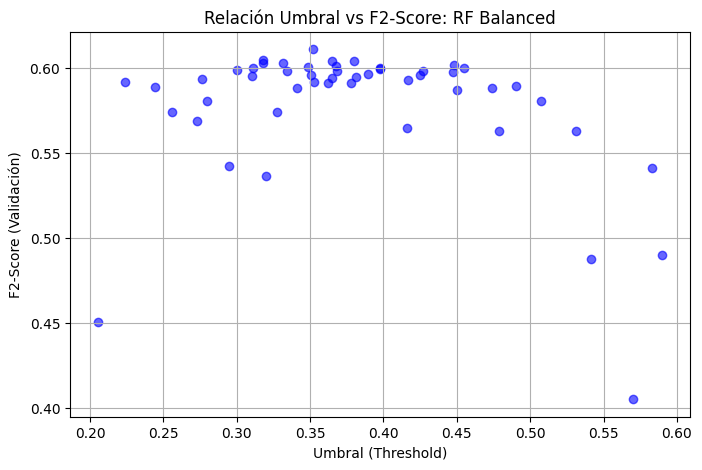

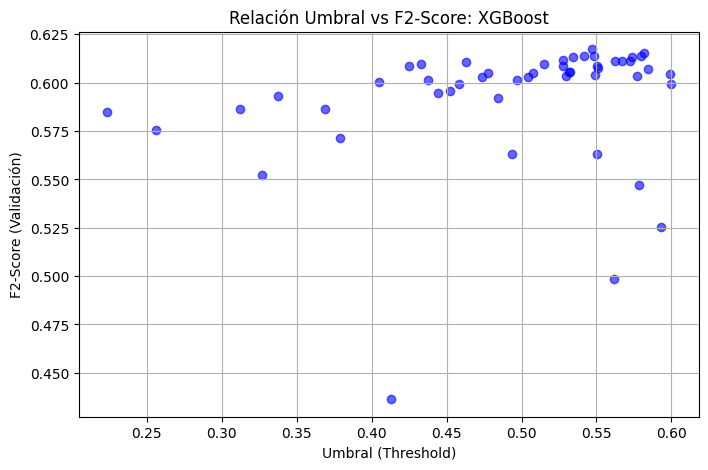

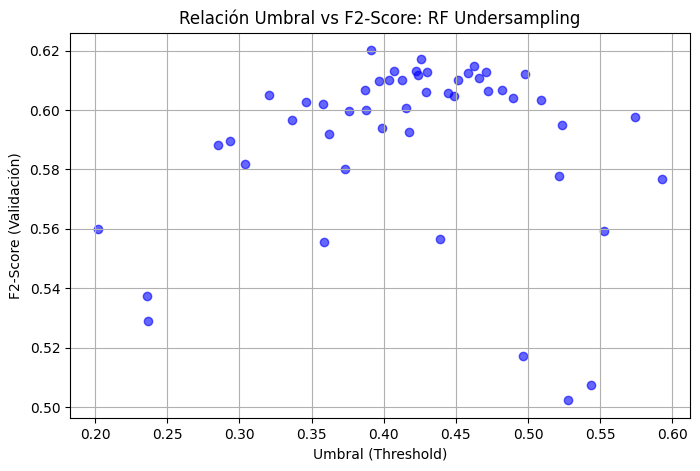

In [ ]:
# import matplotlib.pyplot as plt

# def plot_optimization_history(study, title):
#     # Extraemos los datos de los trials
#     trials = study.trials
#     thresholds = [t.params['threshold'] for t in trials if t.value is not None]
#     values = [t.value for t in trials if t.value is not None]

#     plt.figure(figsize=(8, 5))
#     plt.scatter(thresholds, values, c='blue', alpha=0.6)
#     plt.title(f'Relación Umbral vs F2-Score: {title}')
#     plt.xlabel('Umbral (Threshold)')
#     plt.ylabel('F2-Score (Validación)')
#     plt.grid(True)
#     plt.show()

# # Visualizamos los 3 estudios
# plot_optimization_history(study_rf_bp, "RF Balanced")
# plot_optimization_history(study_xgb, "XGBoost")
# plot_optimization_history(study_rf_under, "RF Undersampling")


===== RF Balanced (Optuna) ====
---- TRAIN (Full) ----
AUC: 0.9492
Recall: 0.9783
Precision: 0.3234
F1: 0.4861

---- TEST (Promedio CV 5-Folds) ----
AUC: 0.8473
Recall: 0.8499
Precision: 0.2809
F1: 0.4223

---- GAP (Train - CV) ----
AUC gap: 0.1019
Recall gap: 0.1284


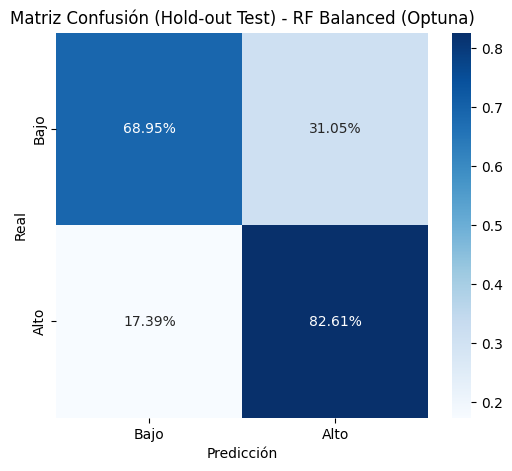


===== XGBoost (Optuna) ====
---- TRAIN (Full) ----
AUC: 0.8808
Recall: 0.8373
Precision: 0.3204
F1: 0.4635

---- TEST (Promedio CV 5-Folds) ----
AUC: 0.8543
Recall: 0.8011
Precision: 0.3158
F1: 0.4528

---- GAP (Train - CV) ----
AUC gap: 0.0266
Recall gap: 0.0361


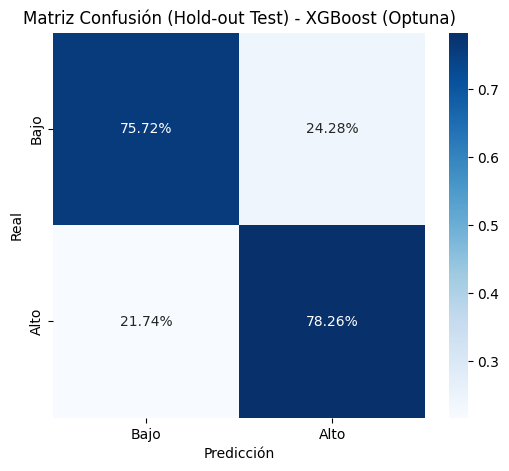


===== RF Undersampling (Optuna) ====
---- TRAIN (Full) ----
AUC: 0.9214
Recall: 0.8427
Precision: 0.7169
F1: 0.7747

---- TEST (Promedio CV 5-Folds) ----
AUC: 0.8493
Recall: 0.7738
Precision: 0.6435
F1: 0.7021

---- GAP (Train - CV) ----
AUC gap: 0.0721
Recall gap: 0.0689


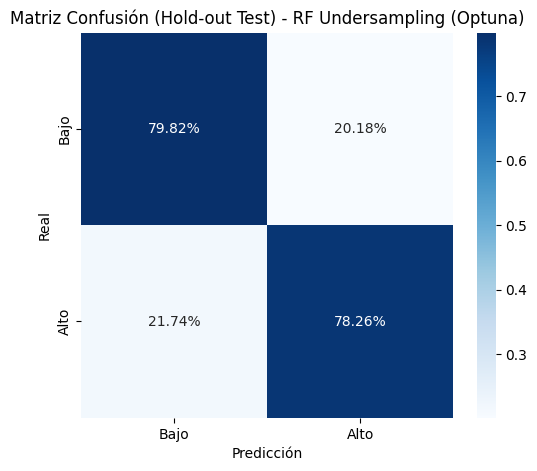

,Modelo,Umbral,auc_train,recall_train,precision_train,f1_train,auc_test,recall_test,precision_test,f1_test,auc_gap,recall_gap
0,RF Balanced (Optuna),0.351701,0.949179,0.978300,0.323371,0.486074,0.847326,0.849910,0.280932,0.422262,0.101853,0.128390
1,XGBoost (Optuna),0.546712,0.880849,0.837251,0.320415,0.463463,0.854264,0.801130,0.315763,0.452834,0.026585,0.036121
2,RF Undersampling (Optuna),0.391305,0.921396,0.842676,0.716923,0.774730,0.849286,0.773792,0.643459,0.702109,0.072110,0.068884


In [ ]:
results = []

best_rf_bp_params = study_rf_bp.best_params.copy()
thresh_rf_bp = best_rf_bp_params.pop('threshold')

modelo_rf_bp_opt = RandomForestClassifier(**best_rf_bp_params, class_weight='balanced', random_state=42)
modelo_rf_bp_opt.fit(X_train_etapa_1, y_train)

rf_bp_opt_metrics = evaluar_overfitting(
    modelo_rf_bp_opt, X_train_etapa_1, y_train, X_test_etapa_1, y_test,
    threshold=thresh_rf_bp, nombre="RF Balanced (Optuna)"
)
results.append({"Modelo": "RF Balanced (Optuna)", "Umbral": thresh_rf_bp, **rf_bp_opt_metrics})

best_xgb_params = study_xgb.best_params.copy()
thresh_xgb = best_xgb_params.pop('threshold')

modelo_xgb_opt = XGBClassifier(**best_xgb_params, random_state=42)
modelo_xgb_opt.fit(X_train_etapa_1, y_train)

xgb_opt_metrics = evaluar_overfitting(
    modelo_xgb_opt, X_train_etapa_1, y_train, X_test_etapa_1, y_test,
    threshold=thresh_xgb, nombre="XGBoost (Optuna)"
)
results.append({"Modelo": "XGBoost (Optuna)", "Umbral": thresh_xgb, **xgb_opt_metrics})

best_rf_under_params = study_rf_under.best_params.copy()
thresh_rf_under = best_rf_under_params.pop('threshold')
samp_strat = best_rf_under_params.pop('sampling_strategy')

undersampler_opt = RandomUnderSampler(sampling_strategy=samp_strat, random_state=42)
X_train_under_opt, y_train_under_opt = undersampler_opt.fit_resample(X_train_etapa_1, y_train)

modelo_rf_under_opt = RandomForestClassifier(**best_rf_under_params, random_state=42)
modelo_rf_under_opt.fit(X_train_under_opt, y_train_under_opt)

rf_under_opt_metrics = evaluar_overfitting(
    modelo_rf_under_opt, X_train_under_opt, y_train_under_opt, X_test_etapa_1, y_test,
    threshold=thresh_rf_under, nombre="RF Undersampling (Optuna)"
)
results.append({"Modelo": "RF Undersampling (Optuna)", "Umbral": thresh_rf_under, **rf_under_opt_metrics})

df_results = pd.DataFrame(results)
display(df_results)

## **Entrenamiento Etapa 2: Básica + Antecedentes + Laboratorio**
Utilizando los hiperparámetros optimizados en la etapa anterior.

In [ ]:
# Definimos los conjuntos de datos para la Etapa 2 (nivel_3_cols)
X_train_etapa_2 = X_train[nivel_3_cols]
X_test_etapa_2 = X_test[nivel_3_cols]

print(f"Dimensiones Etapa 2: {X_train_etapa_2.shape[1]} variables")

Dimensiones Etapa 2: 32 variables



===== RF Balanced (Etapa 2) ====
---- TRAIN (Full) ----
AUC: 0.9705
Recall: 0.9910
Precision: 0.3779
F1: 0.5472

---- TEST (Promedio CV 5-Folds) ----
AUC: 0.8496
Recall: 0.8029
Precision: 0.3080
F1: 0.4451

---- GAP (Train - CV) ----
AUC gap: 0.1209
Recall gap: 0.1881


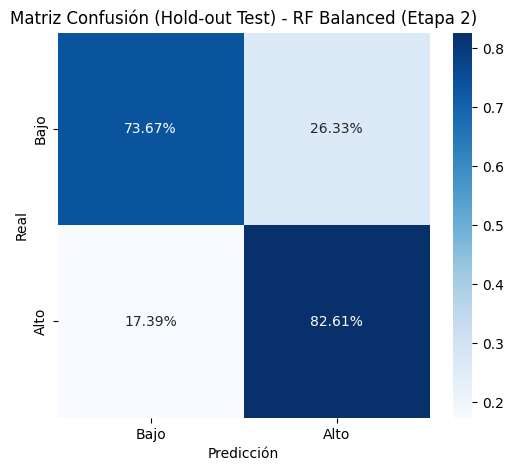


===== XGBoost (Etapa 2) ====
---- TRAIN (Full) ----
AUC: 0.8912
Recall: 0.8463
Precision: 0.3444
F1: 0.4895

---- TEST (Promedio CV 5-Folds) ----
AUC: 0.8547
Recall: 0.7777
Precision: 0.3246
F1: 0.4579

---- GAP (Train - CV) ----
AUC gap: 0.0365
Recall gap: 0.0686


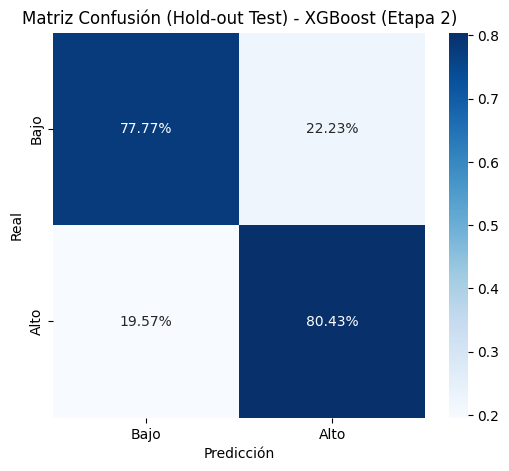


===== RF Undersampling (Etapa 2) ====
---- TRAIN (Full) ----
AUC: 0.9374
Recall: 0.8445
Precision: 0.7581
F1: 0.7990

---- TEST (Promedio CV 5-Folds) ----
AUC: 0.8497
Recall: 0.7485
Precision: 0.6551
F1: 0.6982

---- GAP (Train - CV) ----
AUC gap: 0.0877
Recall gap: 0.0960


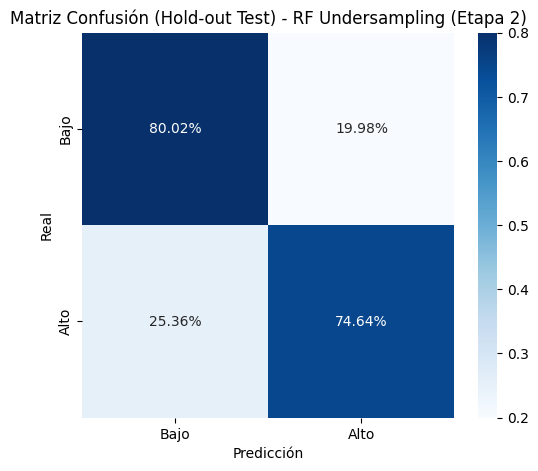

,Modelo,Umbral,auc_train,recall_train,precision_train,f1_train,auc_test,recall_test,precision_test,f1_test,auc_gap,recall_gap
0,RF Balanced (Optuna),0.351701,0.949179,0.978300,0.323371,0.486074,0.847326,0.849910,0.280932,0.422262,0.101853,0.128390
1,XGBoost (Optuna),0.546712,0.880849,0.837251,0.320415,0.463463,0.854264,0.801130,0.315763,0.452834,0.026585,0.036121
2,RF Undersampling (Optuna),0.391305,0.921396,0.842676,0.716923,0.774730,0.849286,0.773792,0.643459,0.702109,0.072110,0.068884
3,RF Balanced (Etapa 2),0.351701,0.970527,0.990958,0.377931,0.547179,0.849643,0.802883,0.307962,0.445139,0.120884,0.188076
4,XGBoost (Etapa 2),0.546712,0.891210,0.846293,0.344371,0.489540,0.854739,0.777658,0.324601,0.457943,0.036471,0.068635
5,RF Undersampling (Etapa 2),0.391305,0.937404,0.844485,0.758117,0.798973,0.849669,0.748518,0.655088,0.698210,0.087735,0.095967


In [ ]:
modelo_rf_bp_e2 = RandomForestClassifier(**best_rf_bp_params, class_weight='balanced', random_state=42)
modelo_rf_bp_e2.fit(X_train_etapa_2, y_train)

rf_bp_e2_metrics = evaluar_overfitting(
    modelo_rf_bp_e2, X_train_etapa_2, y_train, X_test_etapa_2, y_test,
    threshold=thresh_rf_bp, nombre="RF Balanced (Etapa 2)"
)
results.append({"Modelo": "RF Balanced (Etapa 2)", "Umbral": thresh_rf_bp, **rf_bp_e2_metrics})

modelo_xgb_e2 = XGBClassifier(**best_xgb_params, random_state=42)
modelo_xgb_e2.fit(X_train_etapa_2, y_train)

xgb_e2_metrics = evaluar_overfitting(
    modelo_xgb_e2, X_train_etapa_2, y_train, X_test_etapa_2, y_test,
    threshold=thresh_xgb, nombre="XGBoost (Etapa 2)"
)
results.append({"Modelo": "XGBoost (Etapa 2)", "Umbral": thresh_xgb, **xgb_e2_metrics})

undersampler_e2 = RandomUnderSampler(sampling_strategy=samp_strat, random_state=42)
X_train_under_e2, y_train_under_e2 = undersampler_e2.fit_resample(X_train_etapa_2, y_train)

modelo_rf_under_e2 = RandomForestClassifier(**best_rf_under_params, random_state=42)
modelo_rf_under_e2.fit(X_train_under_e2, y_train_under_e2)

rf_under_e2_metrics = evaluar_overfitting(
    modelo_rf_under_e2, X_train_under_e2, y_train_under_e2, X_test_etapa_2, y_test,
    threshold=thresh_rf_under, nombre="RF Undersampling (Etapa 2)"
)
results.append({"Modelo": "RF Undersampling (Etapa 2)", "Umbral": thresh_rf_under, **rf_under_e2_metrics})

df_results = pd.DataFrame(results)
display(df_results)

## **Optimización de Hiperparámetros específica para la Etapa 2**
Buscamos maximizar el F2-Score considerando el nuevo conjunto de 32 variables.

In [ ]:
def objective_rf_bp_e2(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 400),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 25),
        'class_weight': 'balanced',
        'random_state': 42
    }
    threshold = trial.suggest_float('threshold', 0.2, 0.6)
    clf = RandomForestClassifier(**params)
    skf = StratifiedKFold(n_splits=5)
    scores = []
    for train_idx, val_idx in skf.split(X_train_etapa_2, y_train):
        X_t, X_v = X_train_etapa_2.iloc[train_idx], X_train_etapa_2.iloc[val_idx]
        y_t, y_v = y_train.iloc[train_idx], y_train.iloc[val_idx]
        clf.fit(X_t, y_t)
        probs = clf.predict_proba(X_v)[:, 1]
        preds = (probs >= threshold).astype(int)
        scores.append(fbeta_score(y_v, preds, beta=2))
    return np.mean(scores)

def objective_xgb_e2(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 600),
        'max_depth': trial.suggest_int('max_depth', 2, 7),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 0.9),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 5, 15),
        'random_state': 42,
        'eval_metric': 'aucpr'
    }
    threshold = trial.suggest_float('threshold', 0.2, 0.6)
    clf = XGBClassifier(**params)
    skf = StratifiedKFold(n_splits=5)
    scores = []
    for train_idx, val_idx in skf.split(X_train_etapa_2, y_train):
        clf.fit(X_train_etapa_2.iloc[train_idx], y_train.iloc[train_idx])
        probs = clf.predict_proba(X_train_etapa_2.iloc[val_idx])[:, 1]
        preds = (probs >= threshold).astype(int)
        scores.append(fbeta_score(y_train.iloc[val_idx], preds, beta=2))
    return np.mean(scores)

print("Optimizando modelos para Etapa 2...")
study_rf_bp_e2 = optuna.create_study(direction='maximize')
study_rf_bp_e2.optimize(objective_rf_bp_e2, n_trials=50)

study_xgb_e2 = optuna.create_study(direction='maximize')
study_xgb_e2.optimize(objective_xgb_e2, n_trials=50)

print(f"Mejor F2 RF E2: {study_rf_bp_e2.best_value:.4f}")
print(f"Mejor F2 XGB E2: {study_xgb_e2.best_value:.4f}")

[I 2026-04-11 01:09:47,679] A new study created in memory with name: no-name-6d184570-aec4-4439-868f-798cadb430c0


Optimizando modelos para Etapa 2...


[I 2026-04-11 01:09:55,845] Trial 0 finished with value: 0.6078872987783754 and parameters: {'n_estimators': 198, 'max_depth': 12, 'min_samples_split': 21, 'threshold': 0.2997134409720009}. Best is trial 0 with value: 0.6078872987783754.
[I 2026-04-11 01:10:00,775] Trial 1 finished with value: 0.6079799877505552 and parameters: {'n_estimators': 135, 'max_depth': 11, 'min_samples_split': 18, 'threshold': 0.32228762099599984}. Best is trial 1 with value: 0.6079799877505552.
[I 2026-04-11 01:10:06,308] Trial 2 finished with value: 0.5949138152060699 and parameters: {'n_estimators': 250, 'max_depth': 4, 'min_samples_split': 18, 'threshold': 0.5218321233931145}. Best is trial 1 with value: 0.6079799877505552.
[I 2026-04-11 01:10:10,818] Trial 3 finished with value: 0.6017455806474107 and parameters: {'n_estimators': 155, 'max_depth': 8, 'min_samples_split': 7, 'threshold': 0.31532119508985235}. Best is trial 1 with value: 0.6079799877505552.
[I 2026-04-11 01:10:23,985] Trial 4 finished with

Mejor F2 RF E2: 0.6169
Mejor F2 XGB E2: 0.6264


In [ ]:
def objective_rf_under_e2(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'random_state': 42
    }
    sampling_strategy = trial.suggest_float('sampling_strategy', 0.5, 1.0)
    threshold = trial.suggest_float('threshold', 0.2, 0.6)

    undersampler_trial = RandomUnderSampler(sampling_strategy=sampling_strategy, random_state=42)

    skf = StratifiedKFold(n_splits=5)
    scores = []
    for train_idx, val_idx in skf.split(X_train_etapa_2, y_train):
        # Undersampling solo en el set de entrenamiento del fold
        X_t_fold, y_t_fold = undersampler_trial.fit_resample(X_train_etapa_2.iloc[train_idx], y_train.iloc[train_idx])

        clf = RandomForestClassifier(**params)
        clf.fit(X_t_fold, y_t_fold)

        probs = clf.predict_proba(X_train_etapa_2.iloc[val_idx])[:, 1]
        preds = (probs >= threshold).astype(int)
        scores.append(fbeta_score(y_train.iloc[val_idx], preds, beta=2))

    return np.mean(scores)

print("Optimizando RF Undersampling para Etapa 2...")
study_rf_under_e2 = optuna.create_study(direction='maximize')
study_rf_under_e2.optimize(objective_rf_under_e2, n_trials=50)

print(f"Mejor F2 RF Under E2: {study_rf_under_e2.best_value:.4f}")

[I 2026-04-11 01:19:23,065] A new study created in memory with name: no-name-54021ebc-b3ff-4b1f-972f-ad309398daa5


Optimizando RF Undersampling para Etapa 2...


[I 2026-04-11 01:19:26,103] Trial 0 finished with value: 0.545235982327996 and parameters: {'n_estimators': 161, 'max_depth': 6, 'sampling_strategy': 0.6580424600957726, 'threshold': 0.21097033207408045}. Best is trial 0 with value: 0.545235982327996.
[I 2026-04-11 01:19:28,916] Trial 1 finished with value: 0.6098484029360476 and parameters: {'n_estimators': 169, 'max_depth': 10, 'sampling_strategy': 0.9841978233409732, 'threshold': 0.5549864962526484}. Best is trial 1 with value: 0.6098484029360476.
[I 2026-04-11 01:19:31,207] Trial 2 finished with value: 0.598120675687225 and parameters: {'n_estimators': 178, 'max_depth': 4, 'sampling_strategy': 0.6358673799723877, 'threshold': 0.3441645913067864}. Best is trial 1 with value: 0.6098484029360476.
[I 2026-04-11 01:19:32,056] Trial 3 finished with value: 0.5695006823761541 and parameters: {'n_estimators': 66, 'max_depth': 3, 'sampling_strategy': 0.5381312341977242, 'threshold': 0.26584621656746493}. Best is trial 1 with value: 0.6098484

Mejor F2 RF Under E2: 0.6196


## **Entrenamiento Final Etapa 2 con Parámetros Optimizados**


===== RF Balanced (Optuna E2) ====
---- TRAIN (Full) ----
AUC: 0.9807
Recall: 1.0000
Precision: 0.4069
F1: 0.5785

---- TEST (Promedio CV 5-Folds) ----
AUC: 0.8507
Recall: 0.7938
Precision: 0.3151
F1: 0.4512

---- GAP (Train - CV) ----
AUC gap: 0.1300
Recall gap: 0.2062


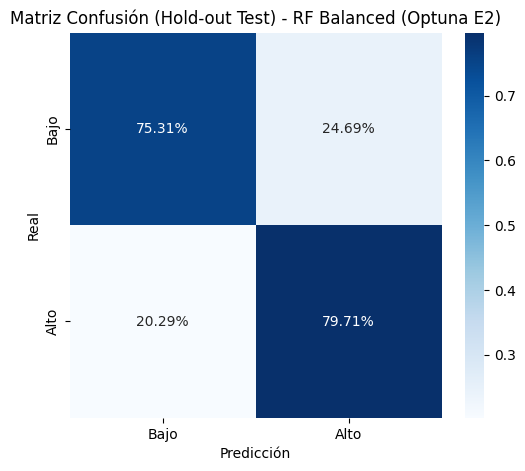


===== XGBoost (Optuna E2) ====
---- TRAIN (Full) ----
AUC: 0.9110
Recall: 0.9114
Precision: 0.3462
F1: 0.5017

---- TEST (Promedio CV 5-Folds) ----
AUC: 0.8499
Recall: 0.7957
Precision: 0.3105
F1: 0.4466

---- GAP (Train - CV) ----
AUC gap: 0.0611
Recall gap: 0.1157


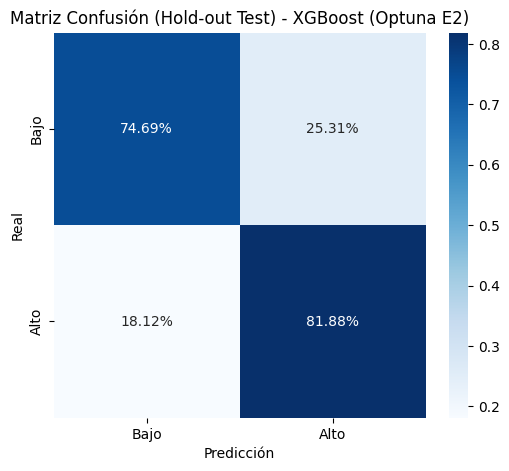

,Modelo,Umbral,auc_train,recall_train,precision_train,f1_train,auc_test,recall_test,precision_test,f1_test,auc_gap,recall_gap
5,RF Undersampling (Etapa 2),0.391305,0.937404,0.844485,0.758117,0.798973,0.849669,0.748518,0.655088,0.698210,0.087735,0.095967
6,RF Balanced (Optuna E2),0.337669,0.980722,1.000000,0.406917,0.578452,0.850712,0.793841,0.315144,0.451166,0.130010,0.206159
7,XGBoost (Optuna E2),0.451615,0.911014,0.911392,0.346154,0.501742,0.849941,0.795659,0.310498,0.446625,0.061073,0.115733


In [ ]:
best_params_rf_e2 = study_rf_bp_e2.best_params.copy()
thresh_rf_e2 = best_params_rf_e2.pop('threshold')
modelo_rf_e2_final = RandomForestClassifier(**best_params_rf_e2, class_weight='balanced', random_state=42)
modelo_rf_e2_final.fit(X_train_etapa_2, y_train)

best_params_xgb_e2 = study_xgb_e2.best_params.copy()
thresh_xgb_e2 = best_params_xgb_e2.pop('threshold')
modelo_xgb_e2_final = XGBClassifier(**best_params_xgb_e2, random_state=42)
modelo_xgb_e2_final.fit(X_train_etapa_2, y_train)

metrics_rf = evaluar_overfitting(modelo_rf_e2_final, X_train_etapa_2, y_train, X_test_etapa_2, y_test, threshold=thresh_rf_e2, nombre="RF Balanced (Optuna E2)")
metrics_xgb = evaluar_overfitting(modelo_xgb_e2_final, X_train_etapa_2, y_train, X_test_etapa_2, y_test, threshold=thresh_xgb_e2, nombre="XGBoost (Optuna E2)")

results.append({"Modelo": "RF Balanced (Optuna E2)", "Umbral": thresh_rf_e2, **metrics_rf})
results.append({"Modelo": "XGBoost (Optuna E2)", "Umbral": thresh_xgb_e2, **metrics_xgb})

display(pd.DataFrame(results).tail(3))


===== RF Under (Optuna E2) ====
---- TRAIN (Full) ----
AUC: 0.9963
Recall: 0.9584
Precision: 0.9567
F1: 0.9575

---- TEST (Promedio CV 5-Folds) ----
AUC: 0.8556
Recall: 0.7721
Precision: 0.7220
F1: 0.7454

---- GAP (Train - CV) ----
AUC gap: 0.1407
Recall gap: 0.1863


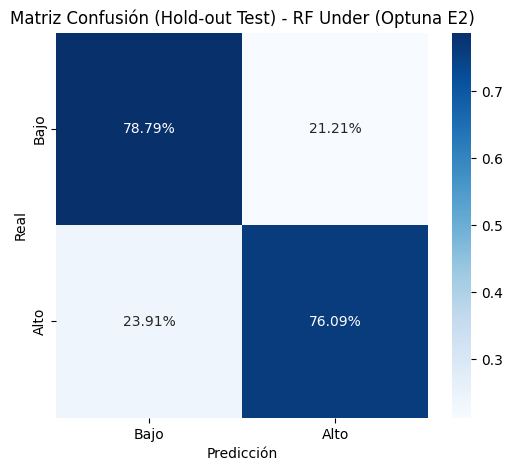

,Modelo,Umbral,auc_train,recall_train,precision_train,f1_train,auc_test,recall_test,precision_test,f1_test,auc_gap,recall_gap
0,RF Balanced (Optuna),0.351701,0.949179,0.978300,0.323371,0.486074,0.847326,0.849910,0.280932,0.422262,0.101853,0.128390
1,XGBoost (Optuna),0.546712,0.880849,0.837251,0.320415,0.463463,0.854264,0.801130,0.315763,0.452834,0.026585,0.036121
2,RF Undersampling (Optuna),0.391305,0.921396,0.842676,0.716923,0.774730,0.849286,0.773792,0.643459,0.702109,0.072110,0.068884
3,RF Balanced (Etapa 2),0.351701,0.970527,0.990958,0.377931,0.547179,0.849643,0.802883,0.307962,0.445139,0.120884,0.188076
4,XGBoost (Etapa 2),0.546712,0.891210,0.846293,0.344371,0.489540,0.854739,0.777658,0.324601,0.457943,0.036471,0.068635
5,RF Undersampling (Etapa 2),0.391305,0.937404,0.844485,0.758117,0.798973,0.849669,0.748518,0.655088,0.698210,0.087735,0.095967
6,RF Balanced (Optuna E2),0.337669,0.980722,1.000000,0.406917,0.578452,0.850712,0.793841,0.315144,0.451166,0.130010,0.206159
7,XGBoost (Optuna E2),0.451615,0.911014,0.911392,0.346154,0.501742,0.849941,0.795659,0.310498,0.446625,0.061073,0.115733
8,RF Under (Optuna E2),0.468040,0.996309,0.958409,0.956679,0.957543,0.855618,0.772088,0.722029,0.745352,0.140691,0.186320


In [ ]:
best_params_rf_under_e2 = study_rf_under_e2.best_params.copy()
thresh_rf_under_e2 = best_params_rf_under_e2.pop('threshold')
samp_strat_e2 = best_params_rf_under_e2.pop('sampling_strategy')

undersampler_e2_final = RandomUnderSampler(sampling_strategy=samp_strat_e2, random_state=42)
X_train_under_e2_opt, y_train_under_e2_opt = undersampler_e2_final.fit_resample(X_train_etapa_2, y_train)

modelo_rf_under_e2_final = RandomForestClassifier(**best_params_rf_under_e2, random_state=42)
modelo_rf_under_e2_final.fit(X_train_under_e2_opt, y_train_under_e2_opt)

metrics_rf_under = evaluar_overfitting(
    modelo_rf_under_e2_final, X_train_under_e2_opt, y_train_under_e2_opt, X_test_etapa_2, y_test,
    threshold=thresh_rf_under_e2, nombre="RF Under (Optuna E2)"
)

results.append({"Modelo": "RF Under (Optuna E2)", "Umbral": thresh_rf_under_e2, **metrics_rf_under})

display(pd.DataFrame(results))


===== RF Balanced (Optuna E2) ====
---- TRAIN (Full) ----
AUC: 0.9807
Recall: 1.0000
Precision: 0.4069
F1: 0.5785

---- TEST (Promedio CV 5-Folds) ----
AUC: 0.8507
Recall: 0.7938
Precision: 0.3151
F1: 0.4512

---- GAP (Train - CV) ----
AUC gap: 0.1300
Recall gap: 0.2062


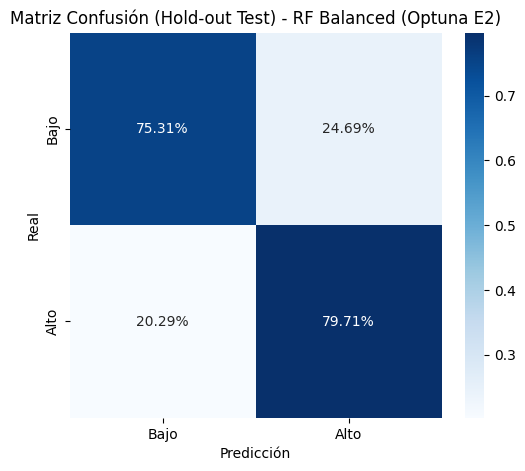


===== XGBoost (Optuna E2) ====
---- TRAIN (Full) ----
AUC: 0.9110
Recall: 0.9114
Precision: 0.3462
F1: 0.5017

---- TEST (Promedio CV 5-Folds) ----
AUC: 0.8499
Recall: 0.7957
Precision: 0.3105
F1: 0.4466

---- GAP (Train - CV) ----
AUC gap: 0.0611
Recall gap: 0.1157


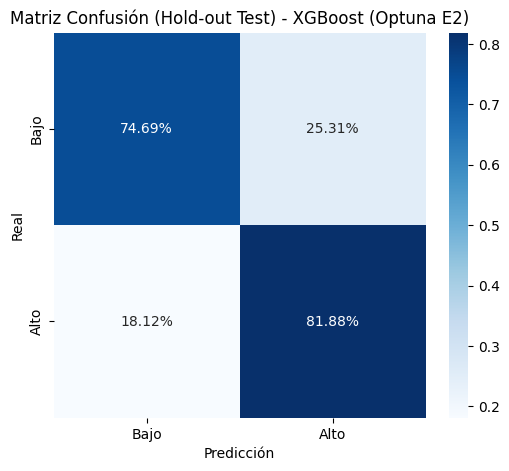


===== RF Under (Optuna E2) ====
---- TRAIN (Full) ----
AUC: 0.9963
Recall: 0.9584
Precision: 0.9567
F1: 0.9575

---- TEST (Promedio CV 5-Folds) ----
AUC: 0.8556
Recall: 0.7721
Precision: 0.7220
F1: 0.7454

---- GAP (Train - CV) ----
AUC gap: 0.1407
Recall gap: 0.1863


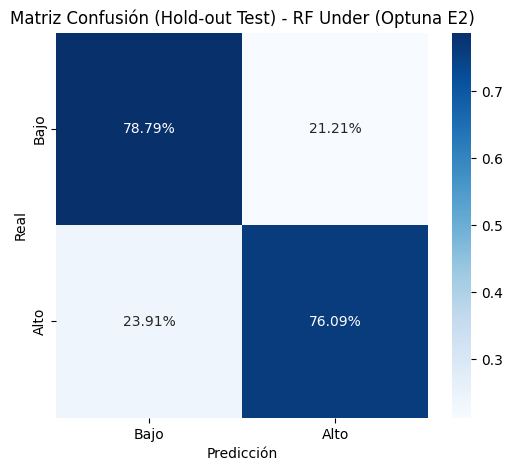

,Modelo,Umbral,auc_train,recall_train,precision_train,f1_train,auc_test,recall_test,precision_test,f1_test,auc_gap,recall_gap
0,RF Balanced (Optuna E2),0.337669,0.980722,1.000000,0.406917,0.578452,0.850712,0.793841,0.315144,0.451166,0.130010,0.206159
1,XGBoost (Optuna E2),0.451615,0.911014,0.911392,0.346154,0.501742,0.849941,0.795659,0.310498,0.446625,0.061073,0.115733
2,RF Under (Optuna E2),0.468040,0.996309,0.958409,0.956679,0.957543,0.855618,0.772088,0.722029,0.745352,0.140691,0.186320


In [ ]:
import pandas as pd

final_comparison = []

metrics_rf_final = evaluar_overfitting(modelo_rf_e2_final, X_train_etapa_2, y_train, X_test_etapa_2, y_test, threshold=thresh_rf_e2, nombre="RF Balanced (Optuna E2)")
final_comparison.append({"Modelo": "RF Balanced (Optuna E2)", "Umbral": thresh_rf_e2, **metrics_rf_final})

metrics_xgb_final = evaluar_overfitting(modelo_xgb_e2_final, X_train_etapa_2, y_train, X_test_etapa_2, y_test, threshold=thresh_xgb_e2, nombre="XGBoost (Optuna E2)")
final_comparison.append({"Modelo": "XGBoost (Optuna E2)", "Umbral": thresh_xgb_e2, **metrics_xgb_final})

metrics_rf_under_final = evaluar_overfitting(modelo_rf_under_e2_final, X_train_under_e2_opt, y_train_under_e2_opt, X_test_etapa_2, y_test, threshold=thresh_rf_under_e2, nombre="RF Under (Optuna E2)")
final_comparison.append({"Modelo": "RF Under (Optuna E2)", "Umbral": thresh_rf_under_e2, **metrics_rf_under_final})

df_final_results = pd.DataFrame(final_comparison)
display(df_final_results)

### **Prueba: Modelos Optuna E2 con Umbrales de la Etapa 1**
Evaluamos si los umbrales definidos con menos variables (Etapa 1) siguen siendo competitivos en los modelos finales de la Etapa 2.


===== RF Balanced (E2 Params + E1 Thresh) ====
---- TRAIN (Full) ----
AUC: 0.9807
Recall: 1.0000
Precision: 0.4297
F1: 0.6011

---- TEST (Promedio CV 5-Folds) ----
AUC: 0.8507
Recall: 0.7704
Precision: 0.3229
F1: 0.4551

---- GAP (Train - CV) ----
AUC gap: 0.1300
Recall gap: 0.2296


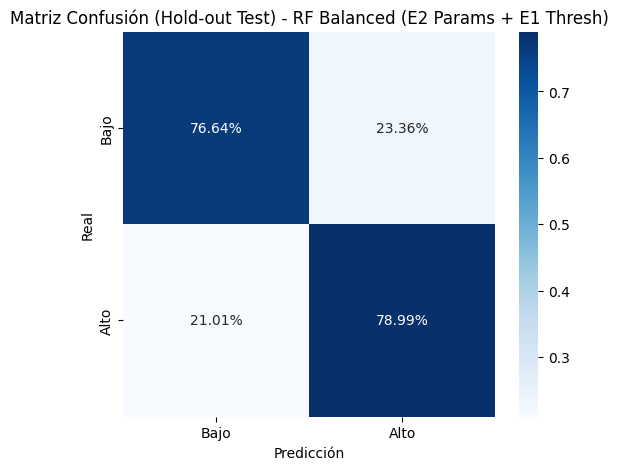


===== XGBoost (E2 Params + E1 Thresh) ====
---- TRAIN (Full) ----
AUC: 0.9110
Recall: 0.8535
Precision: 0.3973
F1: 0.5422

---- TEST (Promedio CV 5-Folds) ----
AUC: 0.8499
Recall: 0.7197
Precision: 0.3497
F1: 0.4704

---- GAP (Train - CV) ----
AUC gap: 0.0611
Recall gap: 0.1338


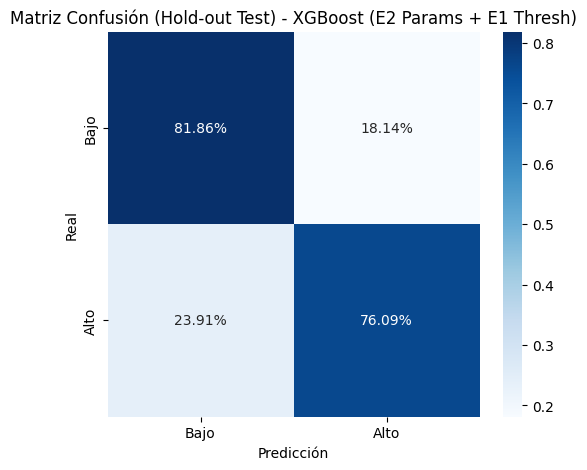


===== RF Under (E2 Params + E1 Thresh) ====
---- TRAIN (Full) ----
AUC: 0.9963
Recall: 0.9928
Precision: 0.9015
F1: 0.9449

---- TEST (Promedio CV 5-Folds) ----
AUC: 0.8556
Recall: 0.8516
Precision: 0.6598
F1: 0.7433

---- GAP (Train - CV) ----
AUC gap: 0.1407
Recall gap: 0.1412


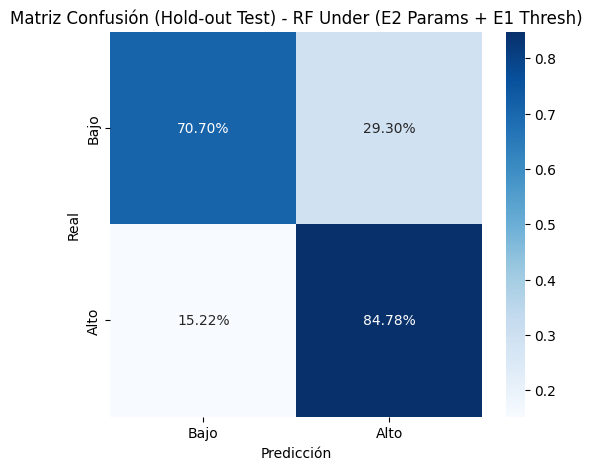

,Modelo,Umbral,auc_train,recall_train,precision_train,f1_train,auc_test,recall_test,precision_test,f1_test,auc_gap,recall_gap
9,RF Balanced (E2+T1),0.351701,0.980722,1.000000,0.429681,0.601087,0.850712,0.770385,0.322947,0.455075,0.130010,0.229615
10,XGBoost (E2+T1),0.546712,0.911014,0.853526,0.397306,0.542217,0.849941,0.719705,0.349651,0.470425,0.061073,0.133821
11,RF Under (E2+T1),0.391305,0.996309,0.992767,0.901478,0.944923,0.855618,0.851613,0.659780,0.743306,0.140691,0.141153


In [ ]:
metrics_rf_cross = evaluar_overfitting(
    modelo_rf_e2_final, X_train_etapa_2, y_train, X_test_etapa_2, y_test,
    threshold=thresh_rf_bp, nombre="RF Balanced (E2 Params + E1 Thresh)"
)
results.append({"Modelo": "RF Balanced (E2+T1)", "Umbral": thresh_rf_bp, **metrics_rf_cross})

metrics_xgb_cross = evaluar_overfitting(
    modelo_xgb_e2_final, X_train_etapa_2, y_train, X_test_etapa_2, y_test,
    threshold=thresh_xgb, nombre="XGBoost (E2 Params + E1 Thresh)"
)
results.append({"Modelo": "XGBoost (E2+T1)", "Umbral": thresh_xgb, **metrics_xgb_cross})

metrics_rf_under_cross = evaluar_overfitting(
    modelo_rf_under_e2_final, X_train_under_e2_opt, y_train_under_e2_opt, X_test_etapa_2, y_test,
    threshold=thresh_rf_under, nombre="RF Under (E2 Params + E1 Thresh)"
)
results.append({"Modelo": "RF Under (E2+T1)", "Umbral": thresh_rf_under, **metrics_rf_under_cross})

display(pd.DataFrame(results).tail(3))

### **Explicación: ¿Cómo se optimiza el Umbral (Threshold)?**

#### **El Proceso con Optuna:**
1. **Propuesta (Sampler):** Optuna utiliza un algoritmo llamado *TPESampler* (Tree-structured Parzen Estimator). Es una forma de **optimización bayesiana** que crea un modelo probabilístico de la función objetivo.
2. **Evaluación:** En lugar de probar todos los valores posibles (como Grid Search), Optuna prueba un valor, observa el **F2-Score** resultante y decide hacia dónde moverse para encontrar el máximo.
3. **Flexibilidad:** Al optimizar el umbral simultáneamente con los parámetros del modelo (como `max_depth`), Optuna encuentra la combinación donde el modelo es lo suficientemente robusto pero también lo suficientemente sensible.

**¿Por qué F2-Score?**
$$\text{F}_\beta = (1 + \beta^2) \cdot \frac{\text{precision} \cdot \text{recall}}{(\beta^2 \cdot \text{precision}) + \text{recall}}$$
Al usar $\beta=2$, le damos **4 veces más peso al Recall** que a la Precisión en la fórmula, forzando a Optuna a buscar umbrales que minimicen los casos de riesgo no detectados.

LOS RESULTADOS QUE SE MUESTRAN A CONTINUACIÓN ESTÁN AGRUPADOS POR MODELO Y SIGUEN EL SIGUIENTE ORDEN:

1. ETAPA 1 OPTIMIZADA Y CON BUSQUEDA DE UMBRAL
2. ETAPA 2 CON HIPERPARÁMETROS Y UMBRAL DE ETAPA 1
3. ETAPA 2 CON BUSQUEDA DE HIPERPARÁMETROS Y UMBRAL PARA ETAPA 2
4. ETAPA 2 CON USO DE UMBRAL DE ETAPA 1 E HIPERPARÁMETROS DE ETAPA 2

### **RAMDOM FOREST BP**

In [ ]:
display(pd.DataFrame(results).iloc[[0, 3, 6, 9]])

# display(df_results.iloc[[0, 3, 6]])

,Modelo,Umbral,auc_train,recall_train,precision_train,f1_train,auc_test,recall_test,precision_test,f1_test,auc_gap,recall_gap
0,RF Balanced (Optuna),0.351701,0.949179,0.978300,0.323371,0.486074,0.847326,0.849910,0.280932,0.422262,0.101853,0.128390
3,RF Balanced (Etapa 2),0.351701,0.970527,0.990958,0.377931,0.547179,0.849643,0.802883,0.307962,0.445139,0.120884,0.188076
6,RF Balanced (Optuna E2),0.337669,0.980722,1.000000,0.406917,0.578452,0.850712,0.793841,0.315144,0.451166,0.130010,0.206159
9,RF Balanced (E2+T1),0.351701,0.980722,1.000000,0.429681,0.601087,0.850712,0.770385,0.322947,0.455075,0.130010,0.229615


### **XGBOOST**

In [ ]:
display(pd.DataFrame(results).iloc[[1, 4, 7, 10]])
# display(df_results.iloc[[1, 4, 7]])

,Modelo,Umbral,auc_train,recall_train,precision_train,f1_train,auc_test,recall_test,precision_test,f1_test,auc_gap,recall_gap
1,XGBoost (Optuna),0.546712,0.880849,0.837251,0.320415,0.463463,0.854264,0.801130,0.315763,0.452834,0.026585,0.036121
4,XGBoost (Etapa 2),0.546712,0.891210,0.846293,0.344371,0.489540,0.854739,0.777658,0.324601,0.457943,0.036471,0.068635
7,XGBoost (Optuna E2),0.451615,0.911014,0.911392,0.346154,0.501742,0.849941,0.795659,0.310498,0.446625,0.061073,0.115733
10,XGBoost (E2+T1),0.546712,0.911014,0.853526,0.397306,0.542217,0.849941,0.719705,0.349651,0.470425,0.061073,0.133821


### **RAMDOM FORREST UNDER**

In [ ]:
display(pd.DataFrame(results).iloc[[2, 5, 8, 11]])

# display(df_results.iloc[[2, 5, 8]])

,Modelo,Umbral,auc_train,recall_train,precision_train,f1_train,auc_test,recall_test,precision_test,f1_test,auc_gap,recall_gap
2,RF Undersampling (Optuna),0.391305,0.921396,0.842676,0.716923,0.774730,0.849286,0.773792,0.643459,0.702109,0.072110,0.068884
5,RF Undersampling (Etapa 2),0.391305,0.937404,0.844485,0.758117,0.798973,0.849669,0.748518,0.655088,0.698210,0.087735,0.095967
8,RF Under (Optuna E2),0.468040,0.996309,0.958409,0.956679,0.957543,0.855618,0.772088,0.722029,0.745352,0.140691,0.186320
11,RF Under (E2+T1),0.391305,0.996309,0.992767,0.901478,0.944923,0.855618,0.851613,0.659780,0.743306,0.140691,0.141153


## **Interpretabilidad del Modelo: Influencia de Variables (XGBoost)**
Utilizaremos la importancia nativa de XGBoost y los valores SHAP para entender cómo cada variable clínica afecta el riesgo del paciente.

<Figure size 1000x800 with 0 Axes>

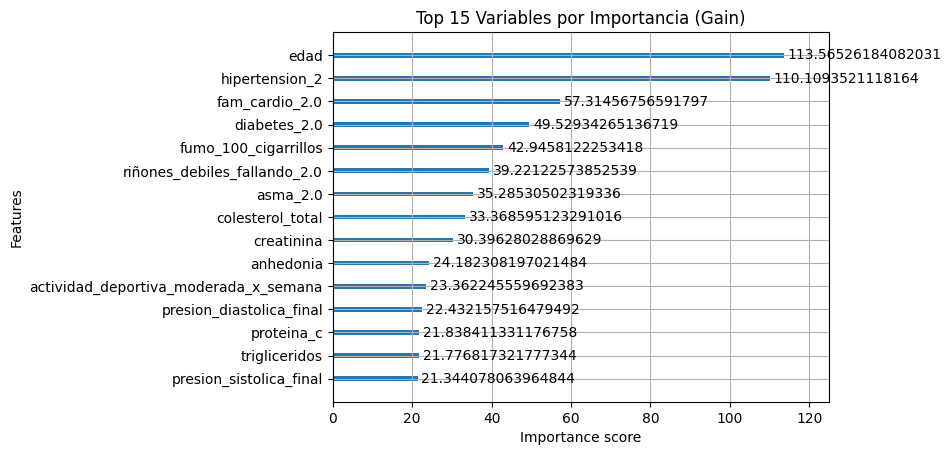

In [ ]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plt.figure(figsize=(10, 8))
plot_importance(modelo_xgb_e2_final, importance_type='gain', max_num_features=15, title='Top 15 Variables por Importancia (Gain)')
plt.show()

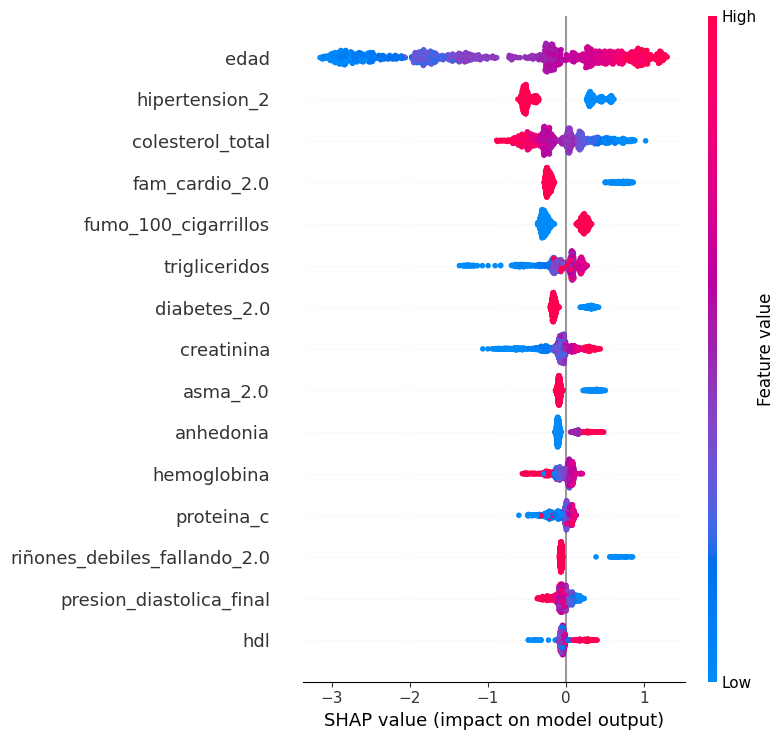

In [ ]:
try:
    import shap
except ImportError:
    !pip install shap
    import shap


explainer = shap.TreeExplainer(modelo_xgb_e2_final)
shap_values = explainer.shap_values(X_test_etapa_2)

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_etapa_2, max_display=15, plot_type="dot")